In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

In [3]:
img_data = pd.read_csv("/content/drive/MyDrive/Colab/final_dataset.csv")

In [4]:
img_data.tail()

,img,label
2118,img_1272.jpg,1.0
2119,img_1273.jpg,1.0
2120,img_1274.jpg,1.0
2121,img_1275.jpg,1.0
2122,img_1276.jpg,1.0


In [ ]:
img_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2123 entries, 0 to 2122
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   img     2123 non-null   object 
 1   label   2123 non-null   float64
dtypes: float64(1), object(1)
memory usage: 33.3+ KB


In [ ]:
imgs_path = "/content/drive/MyDrive/Colab/physionet.org/files/hillel-yaffe-fundus-amd/1.0.0/Images"

In [ ]:
# let's see the image

def display_img(df, path, n):
  subset = df.tail(n)
  for idx, row in subset.iterrows():
    img_path = os.path.join(path, row["img"])
    label = row.get('label', 'No Label')
    img = plt.imread(img_path)
    plt.imshow(img)
    plt.title(f"Label: {label}")
    plt.axis('off')
    plt.show()


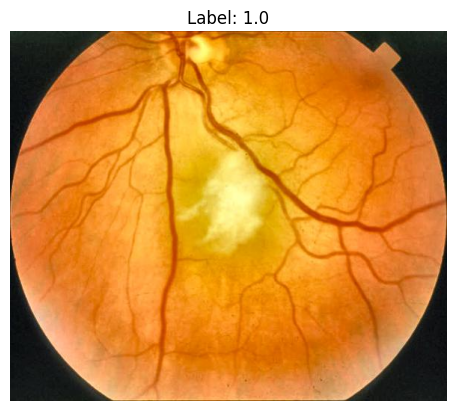

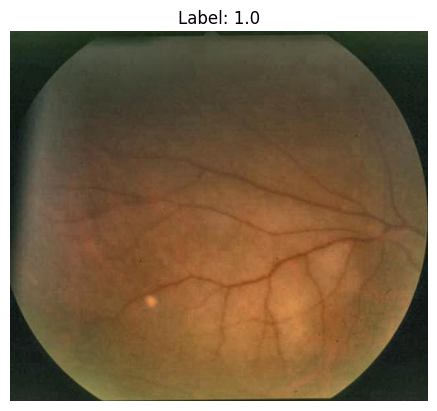

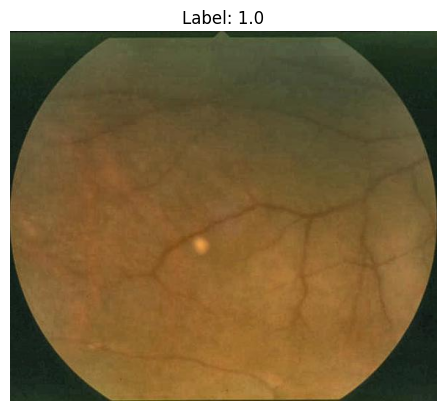

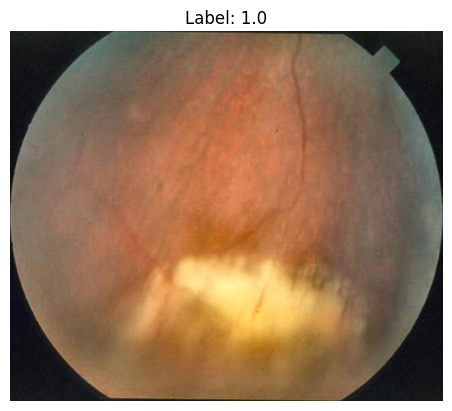

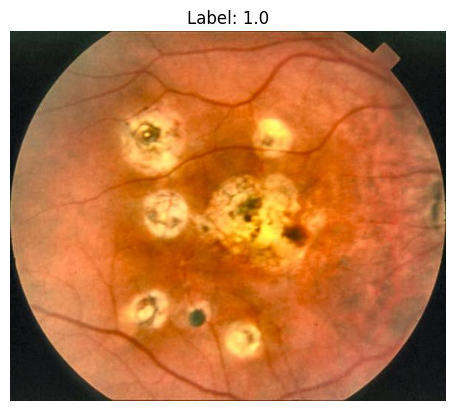

In [ ]:
display_img(img_data, imgs_path, 5)

In [ ]:
# Shuffle the dataset randomly
shuffled_img_data = img_data.sample(frac=1, random_state=42).reset_index(drop=True)

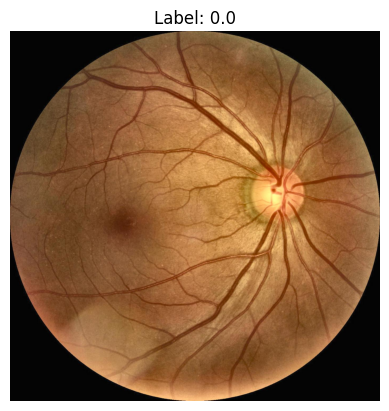

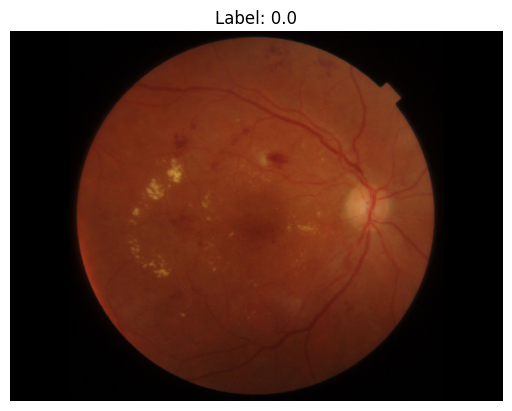

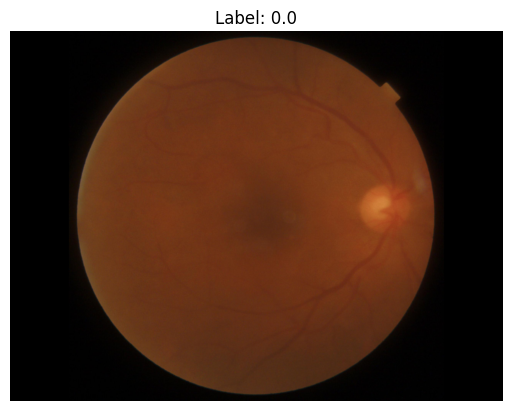

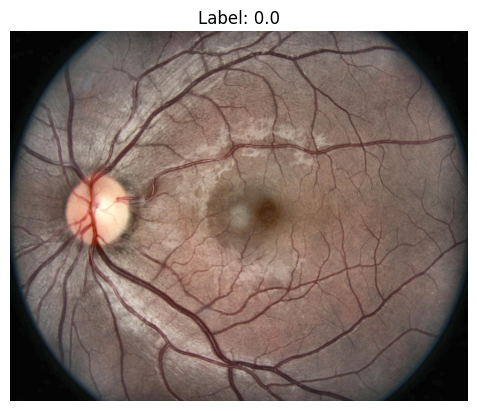

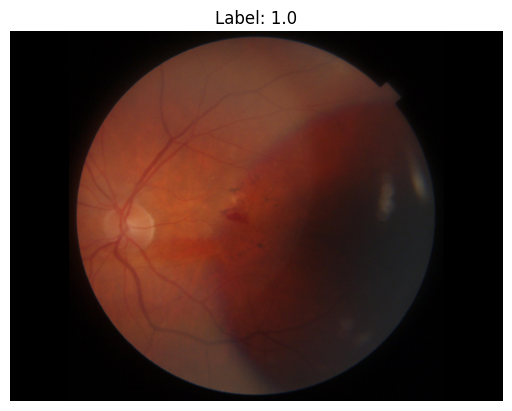

In [ ]:
display_img(shuffled_img_data, imgs_path, 5)

Creating CNN Model(using pretrained resnet-50 then fine-tune it.)

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision.io import read_image
import torchvision.transforms as T
from torch.utils.data import dataloader, TensorDataset
from torchvision.models import ResNet50_Weights
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, f1_score, accuracy_score, classification_report

In [ ]:
from fastai.vision.all import *

In [ ]:
path = Path("/content/drive/MyDrive/Colab/physionet.org/files/hillel-yaffe-fundus-amd/1.0.0/Images")
fns = get_image_files(path)
fns

(#2469) [Path('/content/drive/MyDrive/Colab/physionet.org/files/hillel-yaffe-fundus-amd/1.0.0/Images/962184652_R_5_.png'),Path('/content/drive/MyDrive/Colab/physionet.org/files/hillel-yaffe-fundus-amd/1.0.0/Images/962184652_L_1_.png'),Path('/content/drive/MyDrive/Colab/physionet.org/files/hillel-yaffe-fundus-amd/1.0.0/Images/915656470_R_2_.png'),Path('/content/drive/MyDrive/Colab/physionet.org/files/hillel-yaffe-fundus-amd/1.0.0/Images/999080966_L_1_.png'),Path('/content/drive/MyDrive/Colab/physionet.org/files/hillel-yaffe-fundus-amd/1.0.0/Images/981616684_R_4_.png'),Path('/content/drive/MyDrive/Colab/physionet.org/files/hillel-yaffe-fundus-amd/1.0.0/Images/915656470_L_4_.png'),Path('/content/drive/MyDrive/Colab/physionet.org/files/hillel-yaffe-fundus-amd/1.0.0/Images/996874608_L_6_.png'),Path('/content/drive/MyDrive/Colab/physionet.org/files/hillel-yaffe-fundus-amd/1.0.0/Images/952874991_L_1_.png'),Path('/content/drive/MyDrive/Colab/physionet.org/files/hillel-yaffe-fundus-amd/1.0.0/Im

In [ ]:
dls = ImageDataLoaders.from_df(df= img_data,
                               path = path.parent,
                               folder= path.name,
                               valid_pct=0.2,
                               seed= 2,
                               fn_col= 'img',
                               label_col= 'label',
                               y_block= CategoryBlock,
                               item_tfms= Resize(224),
                               batch_tfms=aug_transforms(
    mult=2,
    max_rotate=15,
    do_flip= True,
    max_lighting=0.2,
    p_lighting=0.75),
                               bs = 32,
                               shuffle= True
                               )

In [ ]:
# dls.show_batch(max_n=2)

In [ ]:
# dls = dls.new(item_tfms=Resize(224, ResizeMethod.Pad, pad_mode = 'Zero'))
# dls.show_batch(max_n=2)

In [ ]:
# dls = dls.new(batch_tfms=aug_transforms(
#     mult=2,
#     max_rotate=0.15,
#     do_flip= True,
#     max_lighting=0.2,
#     p_lighting=0.75))

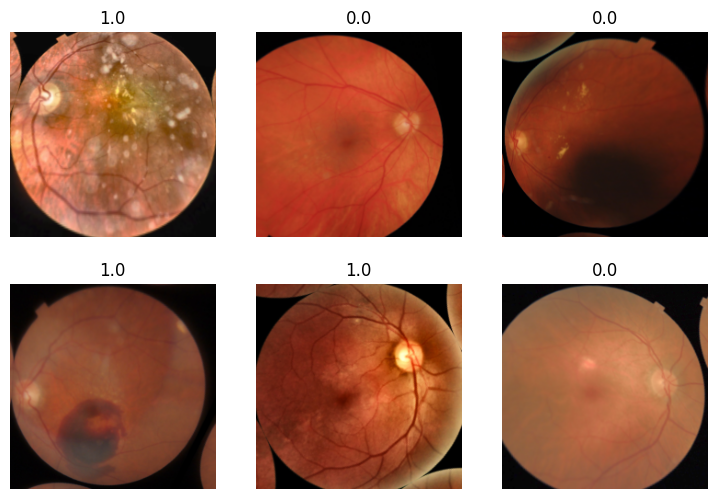

In [ ]:
dls.show_batch(max_n=6)

Training resnet18

In [ ]:
learn = vision_learner(dls, resnet18, metrics= error_rate)
learn.fine_tune(4)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 181MB/s]


epoch,train_loss,valid_loss,error_rate,time
0,0.990666,0.586484,0.224057,03:56


epoch,train_loss,valid_loss,error_rate,time
0,0.837889,0.479333,0.200472,03:30
1,0.684497,0.471996,0.136792,03:33
2,0.578874,0.380512,0.143868,03:33
3,0.497823,0.352112,0.129717,03:29


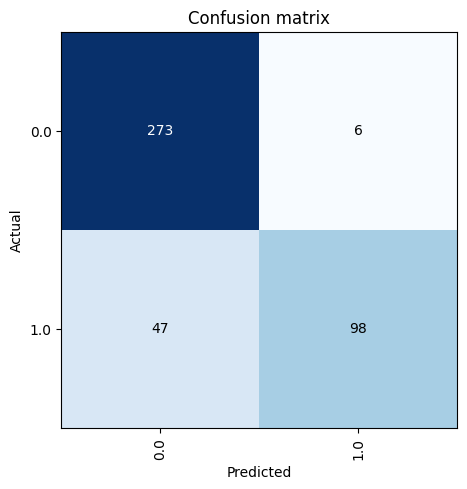

In [ ]:
from fastai.vision.all import ClassificationInterpretation
ClassificationInterpretation.from_learner(learn).plot_confusion_matrix()

training resnet50

In [ ]:
learn_50 = vision_learner(dls, resnet50, weights = ResNet50_Weights.IMAGENET1K_V2, metrics= error_rate)
learn_50.fine_tune(4)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 134MB/s]


epoch,train_loss,valid_loss,error_rate,time
0,0.973988,0.729386,0.233491,03:38


epoch,train_loss,valid_loss,error_rate,time
0,0.750251,0.487857,0.165094,03:35
1,0.642953,0.383201,0.169811,03:42
2,0.547160,0.375457,0.172170,03:40
3,0.473762,0.361326,0.162736,03:40


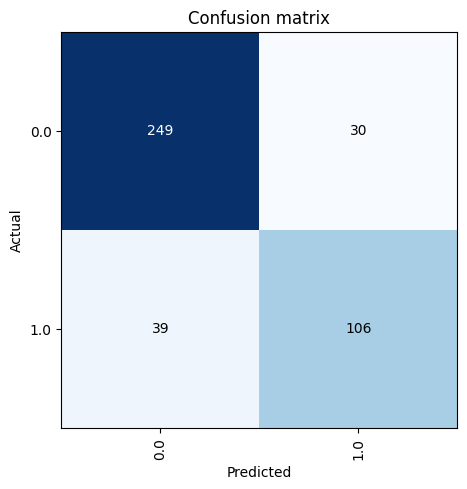

In [ ]:
ClassificationInterpretation.from_learner(learn_50).plot_confusion_matrix()

Training Resnet101

In [ ]:
learn_101 = vision_learner(dls, resnet101, weights= ResNet101_Weights.IMAGENET1K_V2, metrics= error_rate)
learn_101.fine_tune(4)

Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to /root/.cache/torch/hub/checkpoints/resnet101-cd907fc2.pth


100%|██████████| 171M/171M [00:00<00:00, 197MB/s]


epoch,train_loss,valid_loss,error_rate,time
0,1.234023,0.851620,0.308962,03:59


epoch,train_loss,valid_loss,error_rate,time
0,0.892386,0.513015,0.205189,03:50
1,0.733131,0.463600,0.169811,03:45
2,0.577758,0.402569,0.169811,03:44
3,0.466779,0.387256,0.146226,03:44


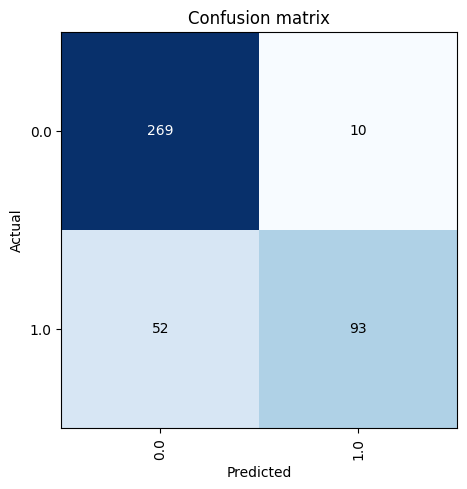

In [ ]:
ClassificationInterpretation.from_learner(learn_101).plot_confusion_matrix()

Training resnet152

In [ ]:
learn_152 = vision_learner(dls, resnet152, weights= ResNet152_Weights.IMAGENET1K_V2, metrics= error_rate)
learn_152.fine_tune(4)

Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:01<00:00, 197MB/s]


epoch,train_loss,valid_loss,error_rate,time
0,1.133473,0.735562,0.245283,03:39


epoch,train_loss,valid_loss,error_rate,time
0,0.788722,0.484277,0.186321,03:47
1,0.692183,0.524977,0.183962,03:45
2,0.530553,0.371383,0.141509,03:44
3,0.440794,0.366713,0.141509,03:42


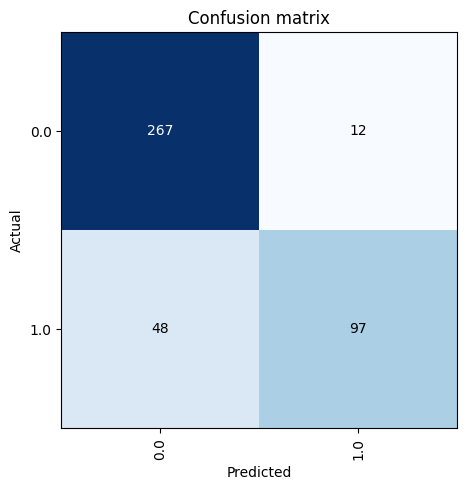

In [ ]:
ClassificationInterpretation.from_learner(learn_152).plot_confusion_matrix()

Going to use Resnet18

In [ ]:
learn = vision_learner(dls, resnet18, metrics=[error_rate, RocAucBinary(), Recall()])
learn.loss_func = CrossEntropyLossFlat(weight=torch.tensor([1.0, 2.5])) # Penalize FN more
learn.fine_tune(5, cbs=SaveModelCallback(monitor='recall_score', fname='bestmodel_18', comp=np.greater))

epoch,train_loss,valid_loss,error_rate,roc_auc_score,recall_score,time
0,1.008717,0.616534,0.193396,0.857447,0.662069,03:23


Better model found at epoch 0 with recall_score value: 0.6620689655172414.


epoch,train_loss,valid_loss,error_rate,roc_auc_score,recall_score,time
0,0.723567,0.606038,0.266509,0.861377,0.848276,03:29
1,0.641987,0.443064,0.261792,0.894401,0.910345,03:27
2,0.539035,0.444199,0.174528,0.904931,0.834483,03:27
3,0.469520,0.454200,0.143868,0.902385,0.800000,03:26
4,0.427796,0.461949,0.153302,0.904981,0.827586,03:25


Better model found at epoch 0 with recall_score value: 0.8482758620689655.
Better model found at epoch 1 with recall_score value: 0.9103448275862069.


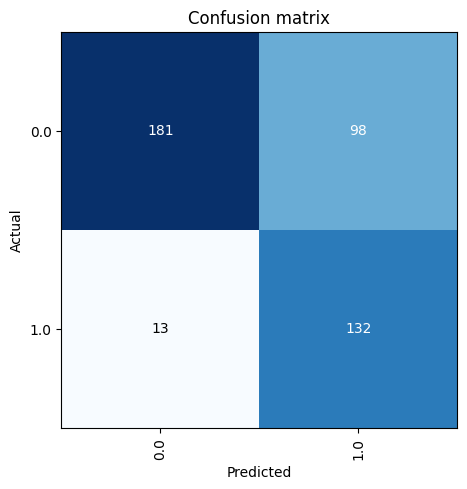

In [ ]:
ClassificationInterpretation.from_learner(learn).plot_confusion_matrix()

In [ ]:
learn.save('final_model_18')

Path('/content/drive/MyDrive/Colab/physionet.org/files/hillel-yaffe-fundus-amd/1.0.0/models/final_model_18.pth')

In [ ]:
learn = vision_learner(dls, resnet18, metrics=[error_rate, RocAucBinary(), Recall()])
learn.loss_func = CrossEntropyLossFlat(weight=torch.tensor([1.0, 1.5])) # Penalize FN more
learn.fine_tune(2, cbs=SaveModelCallback(monitor='recall_score', fname='bestmodel_18', comp=np.greater))

epoch,train_loss,valid_loss,error_rate,roc_auc_score,recall_score,time
0,0.964357,0.568858,0.242925,0.841898,0.731034,03:27


Better model found at epoch 0 with recall_score value: 0.7310344827586207.


epoch,train_loss,valid_loss,error_rate,roc_auc_score,recall_score,time
0,0.717372,0.525730,0.202830,0.873712,0.613793,03:30
1,0.580359,0.404763,0.174528,0.902262,0.800000,03:30


Better model found at epoch 0 with recall_score value: 0.6137931034482759.
Better model found at epoch 1 with recall_score value: 0.8.


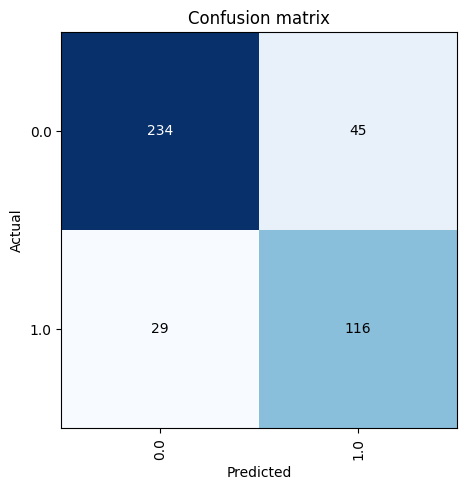

In [ ]:
ClassificationInterpretation.from_learner(learn).plot_confusion_matrix()

In [ ]:
learn.save('final_resnet_model_18')

Path('/content/drive/MyDrive/Colab/physionet.org/files/hillel-yaffe-fundus-amd/1.0.0/models/final_resnet_model_18.pth')

In [ ]:
# learn.fine_tune(6)

In [ ]:
# ClassificationInterpretation.from_learner(learn).plot_confusion_matrix()

Applying Grad-CAM

In [ ]:
learn = vision_learner(dls, resnet18, metrics=[error_rate, RocAucBinary(), Recall()])

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 198MB/s]


In [ ]:
learn.load('final_resnet_model_18')

In [ ]:
model = learn.model.eval()

In [ ]:
model

Sequential(
  (0): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  

In [ ]:
model[0][7][1].conv2

Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)

In [ ]:
tar_layer = model[0][7][1].conv2

In [ ]:
# Get one batch from validation set
xb, yb = dls.valid.one_batch()

In [ ]:
for i in range(len(yb)):
  if yb[i] == 1:
    print(i)

2
8
9
24
26
28
30
31


In [ ]:
img_tensor = xb[31].unsqueeze(0) # [1, 3, 224, 224] for a single image

In [ ]:
# Fastai object to visualize image
img = TensorImage(xb[31])

In [ ]:
img.shape

torch.Size([3, 224, 224])

In [ ]:
# Overlaying the Grad-CAM img on the original img
rgb_img = img.permute(1, 2, 0).cpu().numpy()
rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())

In [ ]:
# !pip install grad-cam

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [ ]:
target_0 = [ClassifierOutputTarget(0)]
target_1 = [ClassifierOutputTarget(1)]

In [ ]:
with GradCAM(model=model,
             target_layers=[tar_layer]) as cam:
  grayscale_cam = cam(input_tensor=img_tensor,
                      targets=target_1)
  grayscale_cam = grayscale_cam[0, :]
  visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

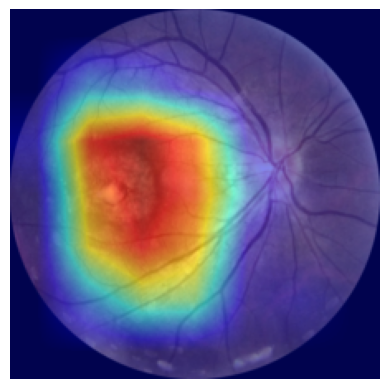

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(visualization)
plt.axis('off')
plt.show()

In [ ]:
act_img = img.permute(1, 2, 0).cpu().numpy()
act_img.shape

(224, 224, 3)

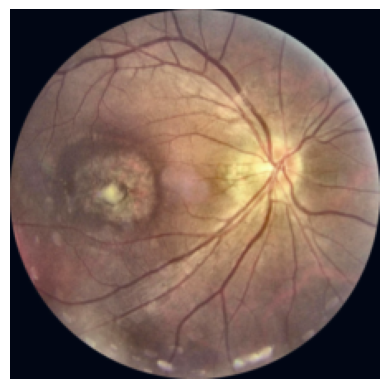

In [ ]:
img_normalized = (act_img - act_img.min()) / (act_img.max() - act_img.min())
plt.imshow(img_normalized)
# plt.imshow(act_img)
plt.axis('off')
plt.show()

In [ ]:
# Get predictions
model.eval()
# Move model to GPU
model.to('cuda')
with torch.no_grad():
    # Move input tensor to GPU
    outputs = model(xb.to('cuda'))
    probabilities = torch.nn.functional.softmax(outputs, dim=1)
    predicted_classes = torch.argmax(probabilities, dim=1)

    # Print results for first few images
    for i in range(min(5, len(xb))):
        print(f"\nImage {i}:")
        print(f"  True label: {yb[i].item()}")
        print(f"  Predicted: {predicted_classes[i].item()}")
        print(f"  Class 0 confidence: {probabilities[i][0].item():.3f}")  # Added .item()
        print(f"  Class 1 confidence: {probabilities[i][1].item():.3f}")  # Added .item()


Image 0:
  True label: 0
  Predicted: 0
  Class 0 confidence: 0.838
  Class 1 confidence: 0.162

Image 1:
  True label: 1
  Predicted: 1
  Class 0 confidence: 0.000
  Class 1 confidence: 1.000

Image 2:
  True label: 1
  Predicted: 1
  Class 0 confidence: 0.421
  Class 1 confidence: 0.579

Image 3:
  True label: 1
  Predicted: 0
  Class 0 confidence: 0.643
  Class 1 confidence: 0.357

Image 4:
  True label: 1
  Predicted: 1
  Class 0 confidence: 0.078
  Class 1 confidence: 0.922


In [ ]:
# Check your training data balance
print(dls.train_ds.items.value_counts())  # or however you store labels

img                 label
img_1276.jpg        1.0      1
000917597_L_1_.png  0.0      1
000917597_L_2_.png  0.0      1
aria_a_14_19.jpg    1.0      1
aria_a_15_35.jpg    1.0      1
                            ..
000917597_R_2_.png  0.0      1
000917597_R_3_.png  0.0      1
000917597_R_4_.png  0.0      1
000917597_R_5_.png  0.0      1
000917597_R_6_.png  0.0      1
Name: count, Length: 1699, dtype: int64


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for xb, yb in dls.valid:
        outputs = model(xb)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=['Normal', 'AMD']))
print("\nConfusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

              precision    recall  f1-score   support

      Normal       0.89      0.84      0.86       279
         AMD       0.72      0.80      0.76       145

    accuracy                           0.83       424
   macro avg       0.81      0.82      0.81       424
weighted avg       0.83      0.83      0.83       424


Confusion Matrix:
[[234  45]
 [ 29 116]]
